In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [2]:
print("Shape:", df.shape)
df.info()
print("\nMissing values:\n", df.isna().sum())
print("\nTarget value counts:\n", df["target"].value_counts())

Shape: (303, 14)
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0

In [3]:
# Impute missing values in ca and thal using median
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

# Confirm no missing values remain
print("Missing values after imputation:\n", df.isna().sum())

# Binarize target: 0 = no disease, 1-4 = disease present -> 1
df["target"] = (df["target"] > 0).astype(int)
print("\nTarget distribution after binarization:\n", df["target"].value_counts())

Missing values after imputation:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target distribution after binarization:
 target
0    164
1    139
Name: count, dtype: int64


In [4]:
df.to_csv("../data/heart_clean.csv", index=False)
print("Saved cleaned dataset:", df.shape)

Saved cleaned dataset: (303, 14)


C:\Users\Arnav_Sreeja\AppData\Local\Temp\ipykernel_9864\3645380890.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="target", data=df, palette=["#4C72B0", "#C44E52"])
C:\Users\Arnav_Sreeja\AppData\Local\Temp\ipykernel_9864\3645380890.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No Disease", "Disease"])


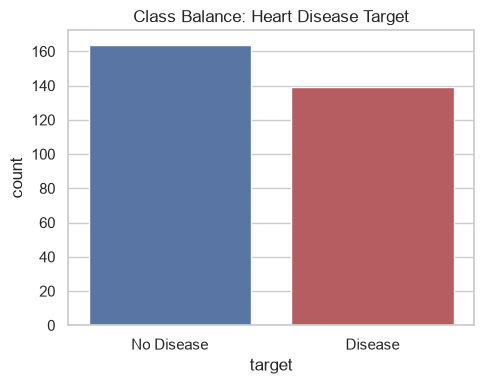

In [7]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="target", data=df, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["No Disease", "Disease"])
ax.set_title("Class Balance: Heart Disease Target")
plt.tight_layout()
plt.savefig("../reports/figures/class_balance.png", dpi=150)
plt.show()

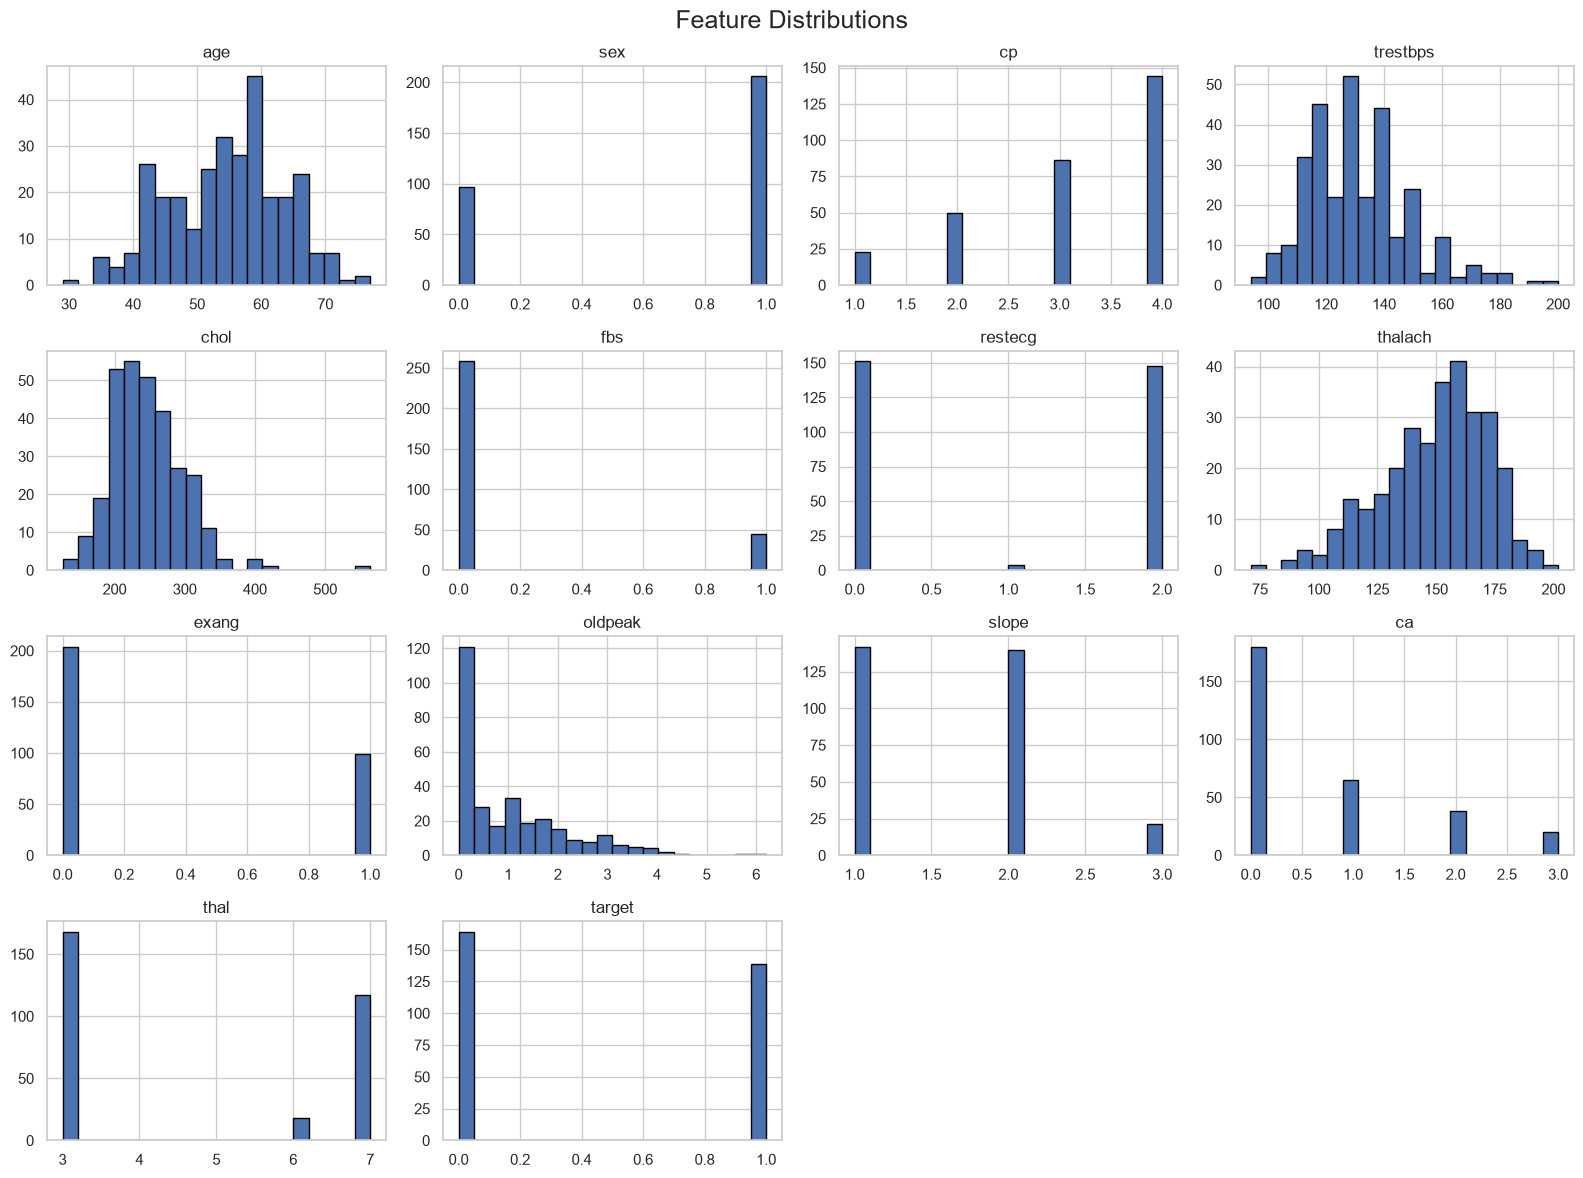

In [8]:
df.hist(figsize=(16, 12), bins=20, color="#4C72B0", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=18)
plt.tight_layout()
plt.savefig("../reports/figures/feature_histograms.png", dpi=150)
plt.show()

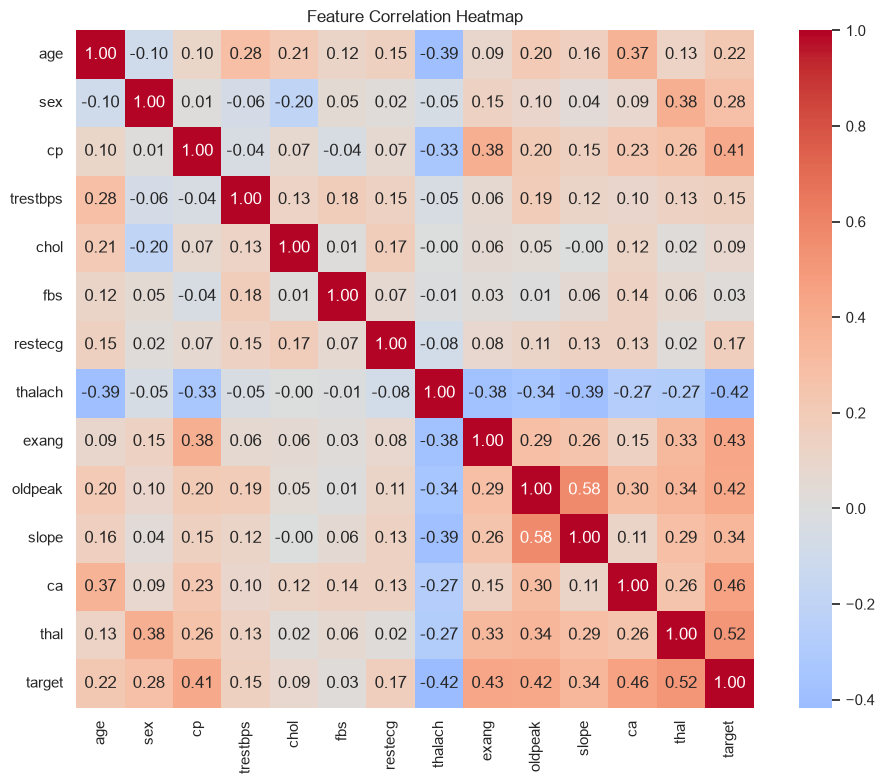

In [9]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=150)
plt.show()

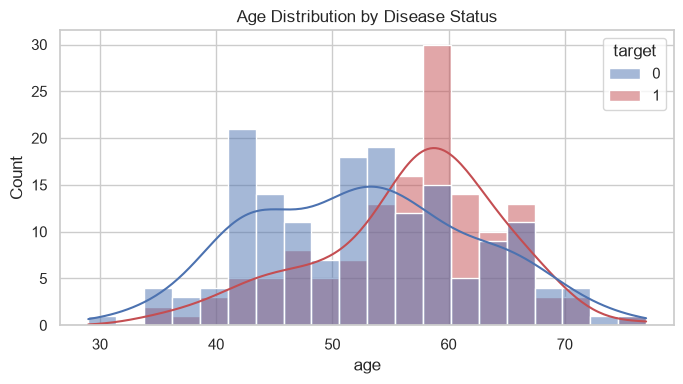

In [10]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="age", hue="target", kde=True, bins=20, palette=["#4C72B0", "#C44E52"])
plt.title("Age Distribution by Disease Status")
plt.tight_layout()
plt.savefig("../reports/figures/age_distribution.png", dpi=150)
plt.show()

C:\Users\Arnav_Sreeja\AppData\Local\Temp\ipykernel_9864\1667706234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, ax=ax, palette=["#4C72B0", "#C44E52"])
C:\Users\Arnav_Sreeja\AppData\Local\Temp\ipykernel_9864\1667706234.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No Disease", "Disease"])
C:\Users\Arnav_Sreeja\AppData\Local\Temp\ipykernel_9864\1667706234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, ax=ax, palette=["#4C72B0", "#C44E52"])
C:\Users\Arnav_Sreeja\AppData\Local\Temp\

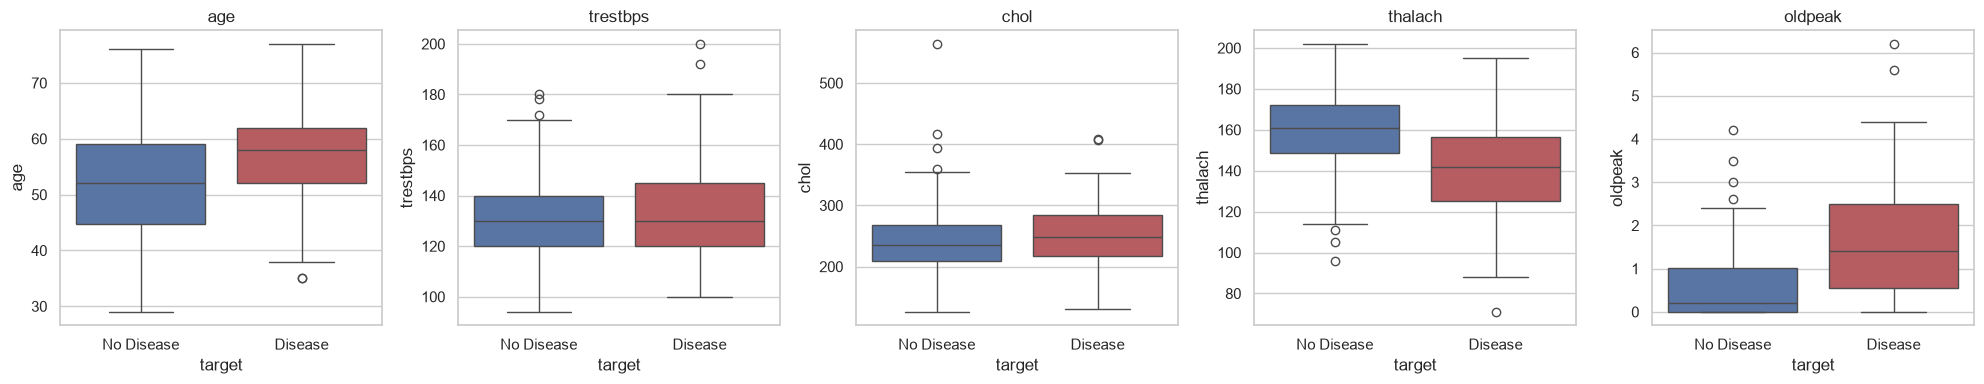

In [11]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x="target", y=col, data=df, ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_xticklabels(["No Disease", "Disease"])
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../reports/figures/boxplots_by_target.png", dpi=150)
plt.show()

In [12]:
import sys
sys.path.append("..")  # so we can import from src/
from src.preprocess import load_clean_data, build_preprocessor, split_data

df = load_clean_data("../data/heart_clean.csv")
X_train, X_test, y_train, y_test = split_data(df)

pre = build_preprocessor()
X_train_transformed = pre.fit_transform(X_train)

print("Original X_train shape:", X_train.shape)
print("Transformed X_train shape:", X_train_transformed.shape)

Original X_train shape: (242, 13)
Transformed X_train shape: (242, 28)
